<a href="https://colab.research.google.com/github/Praveen21-06/DL-LAB-WORK/blob/main/DL_LAB_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1 — Import Required Libraries

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

Step 2 — Load Dataset

In [14]:
data = pd.read_csv("data.csv")
print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


Step 3 — Basic Data Cleaning

In [15]:
data = data.drop(['date','street','city','statezip','country'], axis=1)
print("Columns after cleaning:")
print(data.columns)

Columns after cleaning:
Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated'],
      dtype='object')


Step 4 — Separate Features and Target

In [16]:
X = data.drop("price", axis=1)
y = data["price"]
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (4600, 12)
Target shape: (4600,)


Step 5 — Train Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Step 6 — Feature Scaling

In [18]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Step 7 — Build MLP Model

In [19]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(32, activation='relu'))
model.add(tf.keras.layers.Dense(1))
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,105 (27.75 KB)

 Trainable params: 7,105 (27.75 KB)

 Non-trainable params: 0 (0.00 B)

Step 8 — Train the Model

In [20]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 451725524992.0000 - mae: 553913.3750 - val_loss: 404832583680.0000 - val_mae: 536987.1250
Epoch 2/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 446787584000.0000 - mae: 545282.2500 - val_loss: 399318384640.0000 - val_mae: 533029.1875
Epoch 3/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 436033552384.0000 - mae: 542427.6875 - val_loss: 369207803904.0000 - val_mae: 511223.8750
Epoch 4/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 387555033088.0000 - mae: 503457.4375 - val_loss: 293356273664.0000 - val_mae: 450466.5625
Epoch 5/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 277159280640.0000 - mae: 431255.0000 - val_loss: 188016459776.0000 - val_mae: 342934.5938
Epoch 6/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 181446098944.0000 - mae: 322919.4688 - val_loss: 120344961024.0000 - val_mae: 256810.4375
Epoch 7/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 141293830144.0000 - mae: 256113.0

Step 9 — Model Evaluation

In [21]:
loss, mae = model.evaluate(X_test, y_test)
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("Test MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 184370905088.0000 - mae: 172440.5625
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Test MAE: 203841.859375
RMSE: 990647.8825543125
R2 Score: 0.037714615786464845


Step 10 — Plot Training vs Validation Loss

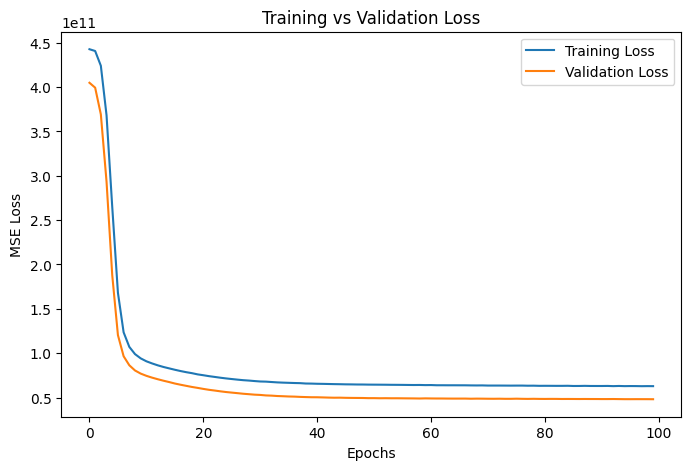

In [22]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

Step 11 — Actual vs Predicted Plot

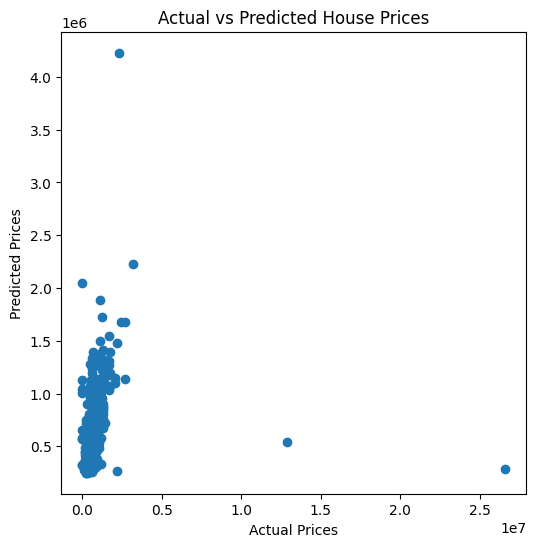

In [23]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

Step 12 — Training with Different Batch Sizes

In [24]:
history_64 = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)

In [25]:
history_128 = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=128,
    validation_split=0.1,
    verbose=0
)

Step 13 — Accuracy-Like Curve

In [26]:
max_val = np.max(y_train)
train_32 = 1 - (np.array(history.history['mae']) / max_val)
val_32 = 1 - (np.array(history.history['val_mae']) / max_val)
train_64 = 1 - (np.array(history_64.history['mae']) / max_val)
val_64 = 1 - (np.array(history_64.history['val_mae']) / max_val)
train_128 = 1 - (np.array(history_128.history['mae']) / max_val)
val_128 = 1 - (np.array(history_128.history['val_mae']) / max_val)

Step 14 — Accuracy Curve Plot

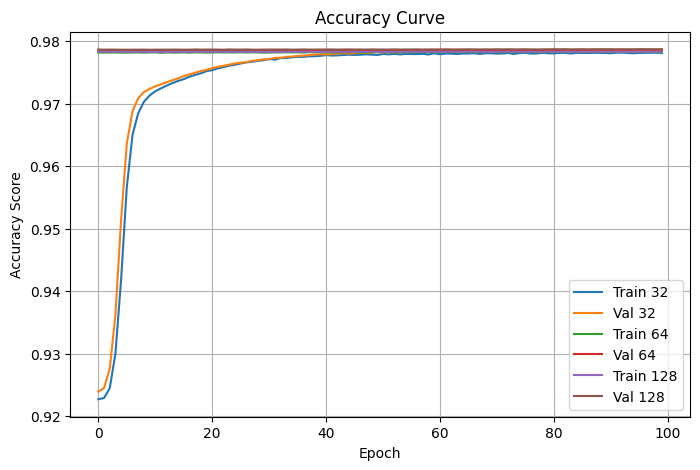

In [27]:
plt.figure(figsize=(8,5))
plt.plot(train_32,label="Train 32")
plt.plot(val_32,label="Val 32")
plt.plot(train_64,label="Train 64")
plt.plot(val_64,label="Val 64")
plt.plot(train_128,label="Train 128")
plt.plot(val_128,label="Val 128")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy Score")
plt.legend()
plt.grid(True)
plt.show()

Step 15 — Effect of Batch Size

In [28]:
Total samples = 4600
Batch Size 32  → 4600 / 32 ≈ 144 updates per epoch
Batch Size 64  → 4600 / 64 ≈ 72 updates per epoch
Batch Size 128 → 4600 / 128 ≈ 36 updates per epoch